# CIFAR-10 Subset Assignment — Question 1 Part (a)

**Dataset:** CIFAR-10 subset (from https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz)  
**Classes:** airplane, car, dog only (3 classes)  
**Splits:** 500 images per class for training, 100 per class for testing

---

## Understanding the Downloaded File

### 1. File type: `.tar.gz`
- **What it is:** A compressed archive (like a .zip).  
  - `.gz` = gzip compression (reduces file size).  
  - `.tar` = "tape archive" — bundles multiple files into one.
- **After download:** You get a single file `cifar-10-python.tar.gz`. We must **extract** it to get the actual data files.

### 2. After extraction: folder `cifar-10-batches-py/`
Inside you will find:
- **`data_batch_1`** through **`data_batch_5`** — training data (no file extension; they are Python pickle files).
- **`test_batch`** — test data (also pickle).
- **`batches.meta`** — metadata (e.g. class names).

### 3. Structure of each batch file (pickle)
- **Format:** Python **pickle** (serialized Python objects). We open with `open(..., 'rb')` and load with `pickle.load(..., encoding='bytes')`.
- **Content:** One dictionary with **byte-string keys** (in Python 3 we use `b'data'`, `b'labels'`, etc.):
  - **`b'data'`**: numpy array of shape `(N, 3072)`. Each row is one image: **3072 = 32×32×3** (32×32 pixels, 3 RGB channels). Pixel order is **all reds, then all greens, then all blues** (see reshape section later).
  - **`b'labels'`**: list of integers 0–9. Each number is the **class index** for that image (see "How we get classes" below).
  - Other keys like `b'filenames'`, `b'batch_label'` exist but we don’t need them for this assignment.

### 4. How we get the classes
- CIFAR-10 has **10 fixed classes**. The official order (and thus label indices) is:
  - **0** = airplane, **1** = automobile (car), **2** = bird, **3** = cat, **4** = deer, **5** = dog, **6** = frog, **7** = horse, **8** = ship, **9** = truck.
- So the **label** stored in each batch is an integer in **0–9**. We use that to know which class each image belongs to.
- For our subset we use only **airplane (0), car (1), dog (5)** — i.e. indices `[0, 1, 5]`.

### 5. How we select our subset
- **Which classes:** We keep only images whose label is in `[0, 1, 5]` (airplane, car, dog).
- **How many:** From the **training** data we take **500 images per class** (1,500 total). From the **test** data we take **100 images per class** (300 total).
- **Which images:** We randomly choose 500 (or 100) indices per class with a fixed random seed (e.g. 42) so the result is reproducible.
- **New labels:** In our subset we remap to 0, 1, 2 (airplane→0, car→1, dog→2) for convenience.

---
## Step-by-step: What is pickle? Why use it? What file did we download? How do we use it?

### Step 1 — What type of file did we download?

We downloaded **one file**: `cifar-10-python.tar.gz`

- **Type:** A **compressed archive** (like a .zip).
- **`.tar.gz`** means: many files were first combined into one **tar** archive, then compressed with **gzip**.
- So we get a **single** file that contains many files inside. We cannot read the images directly from this file — we must **extract** it first. After extraction we get a **folder** (`cifar-10-batches-py`) with several **batch files** inside.

---

### Step 2 — What are the files inside after extraction?

After we extract the `.tar.gz`, we get a folder with files that have **no extension** (e.g. `data_batch_1`, not `data_batch_1.txt`). These are **Python pickle files**. So:

- **Downloaded:** one `.tar.gz` (archive).
- **After extraction:** a folder with **pickle files** (the actual data).

---

### Step 3 — What is pickle?

**Pickle** is Python’s way of **saving and loading Python objects to/from disk**.

- **Normal files** (e.g. `.txt`, `.csv`) store plain text. To get numbers or arrays back, we have to parse the text ourselves.
- **Pickle** stores Python objects (lists, dicts, numpy arrays, etc.) in a **binary** format. When we load the file, we get back the **same** Python object (same type, same shape, same values).

So when the CIFAR-10 creators saved the dataset, they put:
- a **dictionary** (e.g. `{'data': array of images, 'labels': list of class numbers}`)
into a file using pickle. When we **load** that file with `pickle.load()`, we get that dictionary back — we don’t have to parse text or manually read bytes.

---

### Step 4 — Why did CIFAR-10 use pickle?

- The data is **numerical** (thousands of images as arrays of numbers). Storing them in a binary format (pickle) is **compact and fast** to read.
- Pickle can store **numpy arrays and dicts** directly, so the creators could save one dict per batch with keys like `'data'` and `'labels'` and load it in one line in Python.
- So: **we use pickle because the CIFAR-10 dataset was saved in pickle format.** Our code has to **read** that format; we don’t choose the format — the dataset authors did.

---

### Step 5 — How do we use it? (In code)

1. **Extract the archive**  
   We use the `tarfile` module to open `cifar-10-python.tar.gz` and extract it. That gives us the folder with the pickle files.

2. **Open the file in binary mode**  
   Pickle files are binary, so we open with `open(filepath, 'rb')` (`'rb'` = read binary).

3. **Load the Python object**  
   We call `pickle.load(f, encoding='bytes')`. This returns the object that was saved — for CIFAR, a **dict** with:
   - `b'data'` → numpy array of shape `(N, 3072)` (N images, each 32×32×3 = 3072 numbers).
   - `b'labels'` → list/array of N integers (each 0–9), the class index for each image.

4. **Use the data**  
   We take `data` and `labels` from that dict, filter by class (e.g. airplane, car, dog), select 500 train / 100 test per class, and use those arrays for training and testing.

So in short: **downloaded file** = one `.tar.gz` archive → **after extract** = folder of **pickle** batch files → **we use** `pickle.load()` to get a dict with `data` and `labels` → we **select** the 3 classes and the required number of images from those arrays.

## 1. Imports and configuration

In [86]:
# --- Standard library: file paths and downloading ---
import os
import urllib.request
import tarfile
import pickle   # CIFAR-10 batch files are saved as pickle (serialized Python dicts)
import numpy as np
import matplotlib.pyplot as plt

# --- CIFAR-10 class names: we load them from the dataset (batches.meta), not hardcode. See next section. ---

# --- Subset: we use only 3 classes ---
# Original CIFAR-10 indices: airplane=0, automobile=1, dog=5
SUBSET_CLASS_INDICES = [0, 1, 5]  # airplane, car, dog
SUBSET_CLASS_NAMES = ['airplane', 'car', 'dog']  # display names (we say "car" instead of "automobile")

# --- Assignment requirements: 500 train and 100 test per class ---
NUM_TRAIN_PER_CLASS = 500
NUM_TEST_PER_CLASS = 100

# --- Path to the folder that appears after extracting cifar-10-python.tar.gz ---
DATA_DIR = 'cifar-10-batches-py'

## 2. Download and extract CIFAR-10

In [87]:
# URL of the CIFAR-10 dataset (same as in the assignment link)
CIFAR10_URL = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
ARCHIVE_PATH = 'cifar-10-python.tar.gz'  # local name for the downloaded .tar.gz file

# Only download if the archive is not already present (you said you already have it)
if not os.path.exists(ARCHIVE_PATH):
    print('Downloading CIFAR-10...')
    urllib.request.urlretrieve(CIFAR10_URL, ARCHIVE_PATH)
    print('Download complete.')
else:
    print('Archive already exists, skipping download.')

# Extract the .tar.gz so we can read the pickle batch files.
# After this, current directory will contain folder "cifar-10-batches-py" with
# data_batch_1, data_batch_2, ..., data_batch_5, test_batch, batches.meta
if not os.path.exists(DATA_DIR):
    print('Extracting...')
    with tarfile.open(ARCHIVE_PATH, 'r:gz') as tar:  # 'r:gz' = read gzip-compressed tar
        tar.extractall('.')  # extract into current directory
    print('Extraction complete.')
else:
    print('Data directory already exists, skipping extraction.')

Archive already exists, skipping download.
Data directory already exists, skipping extraction.


### Why we get class names from the pickle file (batches.meta)

We **do not** hardcode the list of classes. The CIFAR-10 dataset includes a **metadata** file `batches.meta` (also a pickle file) that contains the official class names in the correct order. So we **load** `CIFAR10_CLASSES` from the dataset — that way we use the same names and order as the dataset authors, and the code works even if we ever use a different version of the dataset.

In [88]:
# Load class names from the dataset's metadata file (batches.meta).
# This file is a pickle containing a dict with key b'label_names': list of 10 class names in order 0-9.
meta_path = os.path.join(DATA_DIR, 'batches.meta')
with open(meta_path, 'rb') as f:
    meta = pickle.load(f, encoding='bytes')
# label_names may be bytes in Python 3; decode to str for display and indexing
raw_names = meta[b'label_names']
CIFAR10_CLASSES = [x.decode('utf-8') if isinstance(x, bytes) else x for x in raw_names]

# Print CIFAR-10 classes from the dataset (index 0 to 9)
print('CIFAR-10 classes (from batches.meta):')
for i, name in enumerate(CIFAR10_CLASSES):
    print(f'  {i}: {name}')
print('All classes:', CIFAR10_CLASSES)

CIFAR-10 classes (from batches.meta):
  0: airplane
  1: automobile
  2: bird
  3: cat
  4: deer
  5: dog
  6: frog
  7: horse
  8: ship
  9: truck
All classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


---
## How to read a binary file and understand it as a human

### Why binary files look like gibberish

- **Text files** (e.g. `.txt`, `.csv`) store characters. Each character has a numeric code (e.g. ASCII/UTF-8). When you open them in an editor, the program interprets those codes as letters and numbers — so you see readable text.
- **Binary files** store raw numbers (bytes): pixel values, floats, integers, or serialized structures (like pickle). If you open a binary file in a text editor or print its bytes as characters, you see random symbols or unreadable output — because the same bytes are **not** meant to be interpreted as text.

So: **you don’t “read” a binary file the same way you read a book.** You need to know **what format** it is (pickle, image, etc.) and use the **right tool** to decode it.

### Two ways to “understand” a binary file as a human

1. **Use the right decoder**  
   For pickle, the decoder is `pickle.load()`. It knows the pickle format and gives you back the original Python object (here, a dict). So we don’t try to “read” the raw bytes; we let Python turn them back into data we can use.

2. **Inspect the decoded result in a human-readable way**  
   After loading, we make the data understandable by:
   - Printing **what’s inside** (e.g. dict keys, list length).
   - Printing **shapes** of arrays (e.g. “10000 images, 3072 values each”).
   - Printing **sample values** (e.g. first few labels, first few pixel values).
   - Optionally **visualizing** (e.g. showing an image with matplotlib).

So the flow is: **binary file → correct decoder (e.g. pickle.load) → Python object → print shapes, keys, and sample values (and maybe plot) to understand it as a human.**

The cells below show: (1) that raw bytes are not readable, and (2) after loading with pickle, how we inspect the result so a human can understand it.

In [89]:
# --- Part 1: Reading raw bytes (what the file really is on disk) ---
# Open in binary mode and read the first 200 bytes. These are NOT meant to be text.
batch_path = os.path.join(DATA_DIR, 'data_batch_1')
with open(batch_path, 'rb') as f:
    raw_bytes = f.read(200)

print("First 200 bytes of the file (raw binary):")
print(raw_bytes)
print("\n→ This is not human-readable. It's pickle's internal format (opcodes + data).")
print("  We do NOT try to interpret this by hand. We use pickle.load() to decode it.\n")

# --- Part 2: Decode with pickle, then inspect in a human-readable way ---
with open(batch_path, 'rb') as f:
    batch = pickle.load(f, encoding='bytes')

# Now we can understand the file: it's a dictionary. Show its keys.
print("After pickle.load(), we get a dictionary with keys:", list(batch.keys()))
print()

# Show shapes so we know how many images and what size
data = batch[b'data']
labels = np.array(batch[b'labels'])
print("Human-readable summary:")
print(f"  Number of images in this batch: {data.shape[0]}")
print(f"  Pixels per image (flat): {data.shape[1]} (= 32×32×3)")
print(f"  Labels shape: {labels.shape}")
print(f"  First 10 labels (class indices 0-9): {labels[:10].tolist()}")
print(f"  As class names: {[CIFAR10_CLASSES[i] for i in labels[:10]]}")
print(f"  First image, first 20 pixel values (red channel start): {data[0, :20].tolist()}")
print("\n→ So: binary file → pickle.load() → dict → we inspect keys, shapes, and sample values to understand it.")

First 200 bytes of the file (raw binary):
b'\x80\x02}q\x01(U\x0bbatch_labelq\x02U\x15training batch 1 of 5q\x03U\x06labelsq\x04]q\x05(K\x06K\tK\tK\x04K\x01K\x01K\x02K\x07K\x08K\x03K\x04K\x07K\x07K\x02K\tK\tK\tK\x03K\x02K\x06K\x04K\x03K\x06K\x06K\x02K\x06K\x03K\x05K\x04K\x00K\x00K\tK\x01K\x03K\x04K\x00K\x03K\x07K\x03K\x03K\x05K\x02K\x02K\x07K\x01K\x01K\x01K\x02K\x02K\x00K\tK\x05K\x07K\tK\x02K\x02K\x05K\x02K\x04K\x03K\x01K\x01K\x08K\x02K\x01K\x01K\x04K\tK\x07K\x08'

→ This is not human-readable. It's pickle's internal format (opcodes + data).
  We do NOT try to interpret this by hand. We use pickle.load() to decode it.

After pickle.load(), we get a dictionary with keys: [b'batch_label', b'labels', b'data', b'filenames']

Human-readable summary:
  Number of images in this batch: 10000
  Pixels per image (flat): 3072 (= 32×32×3)
  Labels shape: (10000,)
  First 10 labels (class indices 0-9): [6, 9, 9, 4, 1, 1, 2, 7, 8, 3]
  As class names: ['frog', 'truck', 'truck', 'deer', 'automobile', 

## 3. Load CIFAR-10 and build 3-class subset

In [90]:
def load_cifar10_batch(filepath):
    """
    Load a single CIFAR-10 batch file (e.g. data_batch_1 or test_batch).
    - File format: pickle. The file contains one Python dict with byte keys.
    - encoding='bytes' is needed in Python 3 so keys come back as b'data', b'labels', etc.
    - Returns: data array (N, 3072), labels array (N,) with values 0-9.
    """
    with open(filepath, 'rb') as f:  # 'rb' = read binary (required for pickle)
        d = pickle.load(f, encoding='bytes')
    # In Python 3, pickle often stores dict keys as bytes; so we use b'data' and b'labels'
    data = d[b'data']           # shape (10000, 3072) per batch; 3072 = 32*32*3
    labels = np.array(d[b'labels'])  # shape (10000,) — each value is class index 0-9
    return data, labels


def load_all_cifar10(data_dir):
    """
    Load full CIFAR-10: all 5 training batches and the test batch.
    - Training: data_batch_1 ... data_batch_5 → 50,000 images total.
    - Test: test_batch → 10,000 images.
    - Returns: train_data (50000, 3072), train_labels (50000,), test_data (10000, 3072), test_labels (10000,).
    """
    train_data, train_labels = [], []
    for i in range(1, 6):  # 1 to 5 inclusive → data_batch_1 through data_batch_5
        path = os.path.join(data_dir, f'data_batch_{i}')
        data, labels = load_cifar10_batch(path)
        train_data.append(data)
        train_labels.append(labels)
    # Stack all training batches into one array
    train_data = np.vstack(train_data)      # (50000, 3072)
    train_labels = np.concatenate(train_labels)  # (50000,)

    test_path = os.path.join(data_dir, 'test_batch')
    test_data, test_labels = load_cifar10_batch(test_path)  # (10000, 3072), (10000,)
    return train_data, train_labels, test_data, test_labels

In [91]:
# Load the full CIFAR-10 dataset from the extracted folder
train_data, train_labels, test_data, test_labels = load_all_cifar10(DATA_DIR)

# Sanity check: we should have 50k train and 10k test; each image is 3072 floats (32*32*3)
print('Full CIFAR-10 (before subset):')
print(f'  Train: {train_data.shape[0]} images, labels shape {train_labels.shape}')
print(f'  Test:  {test_data.shape[0]} images, labels shape {test_labels.shape}')
print(f'  Each image: {train_data.shape[1]} values (32×32×3 = 3072)')

Full CIFAR-10 (before subset):
  Train: 50000 images, labels shape (50000,)
  Test:  10000 images, labels shape (10000,)
  Each image: 3072 values (32×32×3 = 3072)


### Inspecting one batch file (optional — understand the structure)

Below we open **one** batch file and print its keys and array shapes. This shows exactly what the pickle contains.

In [92]:
# Open the first training batch and show what's inside the pickle
batch_path = os.path.join(DATA_DIR, 'data_batch_1')
with open(batch_path, 'rb') as f:
    batch = pickle.load(f, encoding='bytes')

# All keys are bytes in Python 3 (b'data', b'labels', etc.)
print('Keys in the batch dictionary:', list(batch.keys()))
print('Shapes:')
print('  b\'data\':  ', batch[b'data'].shape, '  (num_images, 3072 = 32*32*3)')
print('  b\'labels\':', np.array(batch[b'labels']).shape, '  (num_images,) — each value 0-9')
# Show a few label values and their class names
labels_preview = np.array(batch[b'labels'])[:10]
print('  First 10 labels (CIFAR-10 indices):', labels_preview)
print('  As class names:', [CIFAR10_CLASSES[i] for i in labels_preview])

Keys in the batch dictionary: [b'batch_label', b'labels', b'data', b'filenames']
Shapes:
  b'data':   (10000, 3072)   (num_images, 3072 = 32*32*3)
  b'labels': (10000,)   (num_images,) — each value 0-9
  First 10 labels (CIFAR-10 indices): [6 9 9 4 1 1 2 7 8 3]
  As class names: ['frog', 'truck', 'truck', 'deer', 'automobile', 'automobile', 'bird', 'horse', 'ship', 'cat']


## 4. Filter for 3 classes and take 500 train / 100 test per class

In [93]:
def build_subset(data, labels, class_indices, num_per_class, subset_name='subset'):
    """
    Build a subset with exactly `num_per_class` images per selected class.

    - data: (N, 3072) array of images; labels: (N,) array of CIFAR-10 class indices (0-9).
    - class_indices: which CIFAR-10 classes we want, e.g. [0, 1, 5] for airplane, car, dog.
    - num_per_class: how many images to take per class (500 for train, 100 for test).
    - We remap labels to 0, 1, 2 so our subset uses contiguous class IDs.

    How selection works:
      1. For each class in class_indices, find all indices where labels == that class.
      2. Randomly choose exactly num_per_class of those indices (fixed seed 42 for reproducibility).
      3. Stack the chosen images and assign new labels 0, 1, 2.
      4. Shuffle the combined set so classes are mixed.
    """
    X_list, y_list = [], []
    for new_label, orig_idx in enumerate(class_indices):
        # Boolean mask: True where the image belongs to this CIFAR-10 class
        mask = labels == orig_idx
        indices = np.where(mask)[0]  # array of indices of all images of this class
        if len(indices) < num_per_class:
            raise ValueError(f'{subset_name}: class {orig_idx} has only {len(indices)} samples, need {num_per_class}')
        # Random choice without replacement; RandomState(42) makes it reproducible
        chosen = np.random.RandomState(42).choice(indices, size=num_per_class, replace=False)
        X_list.append(data[chosen])   # (num_per_class, 3072)
        y_list.append(np.full(num_per_class, new_label))  # new labels 0, 1, or 2
    X = np.vstack(X_list)   # (3 * num_per_class, 3072)
    y = np.concatenate(y_list)
    # Shuffle so that batches aren't all one class
    perm = np.random.RandomState(42).permutation(len(y))
    return X[perm], y[perm]


# Build our assignment subset: 500 train and 100 test per class (airplane, car, dog)
X_train, y_train = build_subset(train_data, train_labels, SUBSET_CLASS_INDICES, NUM_TRAIN_PER_CLASS, 'train')
X_test, y_test = build_subset(test_data, test_labels, SUBSET_CLASS_INDICES, NUM_TEST_PER_CLASS, 'test')

In [94]:
# Verify subset sizes and balance
print('3-class subset (airplane, car, dog):')
print(f'  X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'  X_test:  {X_test.shape},  y_test:  {y_test.shape}')
print(f'  Train samples per class: {NUM_TRAIN_PER_CLASS}, test per class: {NUM_TEST_PER_CLASS}')
for i, name in enumerate(SUBSET_CLASS_NAMES):
    print(f'  Class {i} ({name}): train={np.sum(y_train == i)}, test={np.sum(y_test == i)}')

3-class subset (airplane, car, dog):
  X_train: (1500, 3072), y_train: (1500,)
  X_test:  (300, 3072),  y_test:  (300,)
  Train samples per class: 500, test per class: 100
  Class 0 (airplane): train=500, test=100
  Class 1 (car): train=500, test=100
  Class 2 (dog): train=500, test=100


## 5. Reshape images to (N, 32, 32, 3) for visualization

In [95]:
# --- Reshape flat 3072 vectors into (32, 32, 3) images for display ---
# CIFAR-10 stores each image as a single row of 3072 numbers in this order:
#   [red channel (32*32=1024 values), green channel (1024), blue channel (1024)]
# So we reshape to (3, 32, 32) then transpose to (32, 32, 3) which is height × width × channels (RGB).
def cifar_reshape(flat):
    n = flat.shape[0]
    return flat.reshape(n, 3, 32, 32).transpose(0, 2, 3, 1)  # (N, 32, 32, 3)

X_train_img = cifar_reshape(X_train)
X_test_img = cifar_reshape(X_test)
print('Image shapes (N, height, width, channels):', X_train_img.shape, X_test_img.shape)

Image shapes (N, height, width, channels): (1500, 32, 32, 3) (300, 32, 32, 3)


## 6. Visualize sample images

### Why do we use "smaller" amounts?

- **Number of images (500 train, 100 test per class)**  
  The **assignment** asks for exactly 500 training and 100 test images per class. So we take a **subset** of the full CIFAR-10 (which has 5,000 train and 1,000 test per class). We are not changing the image size — we are using fewer images.

- **Image size (32×32)**  
  We **do not** make the images smaller. CIFAR-10 was created with 32×32 pixel images. That is the native resolution in the dataset; we only reshape the flat 3072 values into 32×32×3 for display and training.

- **Figure size (e.g. `figsize=(10, 3)`)**  
  That sets the **matplotlib figure** size in inches (how big the plot window is on screen). It does **not** change the image data: each image is still 32×32 pixels. Making the figure smaller just fits more panels on the page; the pixel array stays the same.

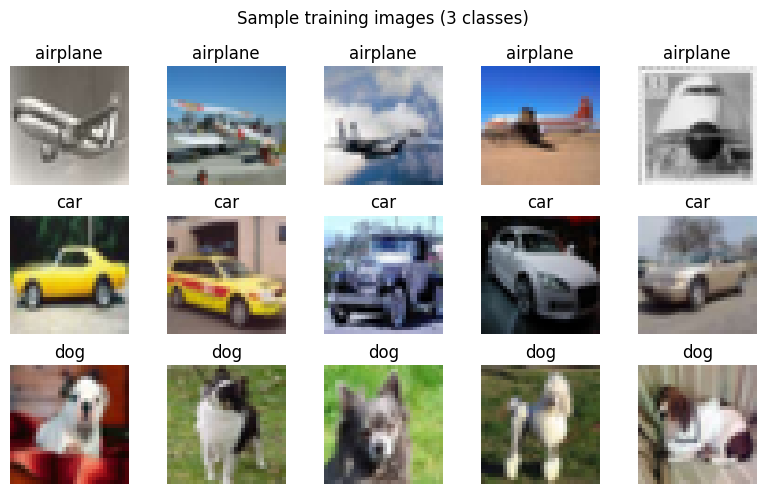

In [96]:
# Show 5 example images per class (airplane, car, dog)
fig, axes = plt.subplots(3, 5, figsize=(8, 5))
for c in range(3):
    idx = np.where(y_train == c)[0][:5]  # first 5 training indices for class c
    for j, i in enumerate(idx):
        axes[c, j].imshow(X_train_img[i])  # imshow expects (H, W, 3) for RGB
        axes[c, j].set_title(SUBSET_CLASS_NAMES[c])
        axes[c, j].axis('off')
plt.suptitle('Sample training images (3 classes)')
plt.tight_layout()
plt.show()

## Summary

| Item | Description |
|------|-------------|
| **Downloaded file** | `cifar-10-python.tar.gz` — gzip-compressed tar archive |
| **After extraction** | Folder `cifar-10-batches-py/` with `data_batch_1`–`data_batch_5`, `test_batch`, `batches.meta` (all pickle format) |
| **Batch contents** | Dict with `b'data'` (N×3072) and `b'labels'` (N,) — labels are integers 0–9 |
| **Classes used** | airplane (0), car/automobile (1), dog (5) → remapped to 0, 1, 2 in our subset |
| **Training** | 500 images per class → 1,500 total (`X_train`, `y_train`) |
| **Testing** | 100 images per class → 300 total (`X_test`, `y_test`) |
| **Image layout** | Flat: (N, 3072); for display: `X_train_img`, `X_test_img` with shape (N, 32, 32, 3) |

### Why did the dataset creators use three separate bands (R, G, B)?

**1. Why three channels at all?**  
Color images are represented by **three components**: red, green, and blue. Mixing these (e.g. 0–255 per channel) gives the colors we see. So any RGB image has three “bands” of values; the dataset is just storing that standard representation.

**2. Why store them as three separate bands (all reds, then all greens, then all blues)?**  
The creators used a **channel-first** layout (three bands one after another) for a few practical reasons:

- **Simplicity:** One channel is a contiguous block of 1024 values (32×32). Easy to index “all red” or “all green” without striding.
- **Legacy / tools:** When CIFAR-10 was made, a lot of image and neural-net code (including in C and older frameworks) used this “planar” or channel-first format. Storing R, G, B as separate blocks made it straightforward to feed into those pipelines.
- **Per-channel processing:** Some operations (e.g. normalization, filters, or analysis per color) are simpler when each channel is a contiguous block in memory.
- **Compact and consistent:** The layout is fixed (always R then G then B, row-major within each), so reading code and data loaders stay simple.

So: **three bands** because that’s how color (RGB) works; **stored as three separate bands** for convenience, compatibility with older tools, and easy per-channel access. We then reshape/transpose to (32, 32, 3) when we want the “one pixel = (R,G,B)” layout for display or modern libraries.

---
## How is each image saved in the CIFAR batch files?

In the pickle batch files (`data_batch_1` … `test_batch`), images are **not** stored as 32×32 pictures. They are stored in a **flat (1D) array** per image:

| What | Details |
|------|--------|
| **Shape** | Each image is one row of **3072 numbers** (one row in the `b'data'` array). |
| **Why 3072?** | 32 × 32 × 3 = **3072** (32×32 pixels, 3 color channels: red, green, blue). |
| **Order of the 3072 values** | **Channel-first, row-major:** first all **red** values (32×32 = 1024), then all **green** (1024), then all **blue** (1024). Within each channel, pixels are in **row-major** order (row 0 left-to-right, then row 1, …, then row 31). |
| **Data type** | Unsigned 8-bit integers (0–255), i.e. one byte per value. |

So for one image, the layout is:

```
[ R0, R1, ..., R1023,  G0, G1, ..., G1023,  B0, B1, ..., B1023 ]
   ←── 1024 red ──→     ←── 1024 green ──→    ←── 1024 blue ──→
```

To use it as a 2D image (e.g. for display), we **reshape** this flat 3072 into a 32×32×3 array (height × width × channels). The next cell does that.

In [97]:
# Demonstrate how one image is stored: one row of 3072 values (R then G then B)
batch_path = os.path.join(DATA_DIR, 'data_batch_1')
with open(batch_path, 'rb') as f:
    batch = pickle.load(f, encoding='bytes')
data = batch[b'data']
one_image = data[0]  # first image: shape (3072,)
print('One image in the file: shape =', one_image.shape)
print('  Indices   0–1023: red channel   (32×32 values)')
print('  Indices 1024–2047: green channel (32×32 values)')
print('  Indices 2048–3071: blue channel  (32×32 values)')
print('  Example — red at (row=0, col=0):', one_image[0], '  green at (0,0):', one_image[1024], '  blue at (0,0):', one_image[2048])

One image in the file: shape = (3072,)
  Indices   0–1023: red channel   (32×32 values)
  Indices 1024–2047: green channel (32×32 values)
  Indices 2048–3071: blue channel  (32×32 values)
  Example — red at (row=0, col=0): 59   green at (0,0): 62   blue at (0,0): 63


---
## Display images from the numeric pattern (tar/pickle → visual)

Yes — we can display images even though they are stored as a **series of numbers** (one row of 3072 values per image). Steps:

1. Load the batch from the extracted pickle file (from the tar).
2. Take one row (one image) — shape `(3072,)`.
3. **Reshape** to `(32, 32, 3)`: CIFAR stores as R then G then B, so we reshape to `(3, 32, 32)` then transpose to `(32, 32, 3)` for matplotlib.
4. Use `plt.imshow()` to display.

We **cannot** display directly from the `.tar.gz` without extracting first (the tar is an archive; the image data is inside the pickle files). After extraction, we can display **one image** or a **grid of many** from any batch file.

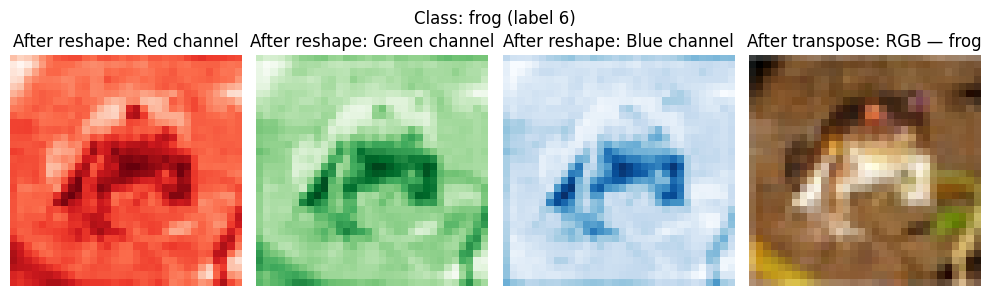

Top row: after reshape (3, 32, 32) — R, G, B channels. Right: after transpose (32, 32, 3) — full image.


In [98]:
# Display ONE image: convert the numeric row (3072) to a 32×32×3 image and show it
# Uses: data, batch from the previous cell (one batch already loaded)
one_row = data[0]  # shape (3072,) — one image as stored in the file

# Why reshape(3, 32, 32).transpose(1, 2, 0)?
# 1) In the file, 3072 is stored as [1024 red, 1024 green, 1024 blue]. So we reshape to
#    (3, 32, 32) = (channels, height, width) — 3 channels of 32×32 each.
# 2) matplotlib imshow() expects (height, width, channels) = (32, 32, 3). So we transpose
#    (1, 2, 0): put axis 1 (height) first, axis 2 (width) second, axis 0 (channels) last.
img_reshaped = one_row.reshape(3, 32, 32)   # (3, 32, 32) — channels first
one_img = img_reshaped.transpose(1, 2, 0)  # (32, 32, 3) — for display
label_idx = batch[b'labels'][0]
class_name = CIFAR10_CLASSES[label_idx]

# Display 1) After reshape only: show the 3 channels (R, G, B) as separate 32×32 images
fig, axes = plt.subplots(1, 4, figsize=(10, 3))
axes[0].imshow(img_reshaped[0], cmap='Reds')   # Red channel (32, 32)
axes[0].set_title('After reshape: Red channel')
axes[0].axis('off')
axes[1].imshow(img_reshaped[1], cmap='Greens') # Green channel
axes[1].set_title('After reshape: Green channel')
axes[1].axis('off')
axes[2].imshow(img_reshaped[2], cmap='Blues')  # Blue channel
axes[2].set_title('After reshape: Blue channel')
axes[2].axis('off')
axes[3].imshow(one_img)                         # Full RGB after transpose
axes[3].set_title(f'After transpose: RGB — {class_name}')
axes[3].axis('off')
plt.suptitle(f'Class: {class_name} (label {label_idx})')
plt.tight_layout()
plt.show()
print('Top row: after reshape (3, 32, 32) — R, G, B channels. Right: after transpose (32, 32, 3) — full image.')

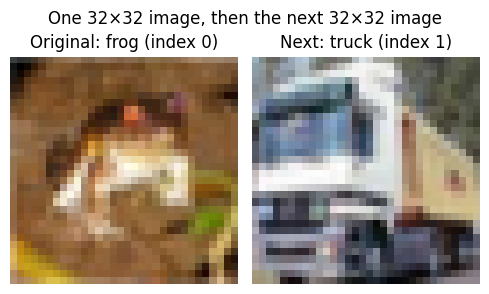

In [99]:
# Original 32×32 image (index 0) and the next one (index 1) as 32×32 pictures
def to_32x32(row):
    return row.reshape(3, 32, 32).transpose(1, 2, 0)  # (32, 32, 3)

fig, axes = plt.subplots(1, 2, figsize=(5, 3))
axes[0].imshow(to_32x32(data[0]))
axes[0].set_title(f'Original: {CIFAR10_CLASSES[batch[b"labels"][0]]} (index 0)')
axes[0].axis('off')
axes[1].imshow(to_32x32(data[1]))
axes[1].set_title(f'Next: {CIFAR10_CLASSES[batch[b"labels"][1]]} (index 1)')
axes[1].axis('off')
plt.suptitle('One 32×32 image, then the next 32×32 image')
plt.tight_layout()
plt.show()

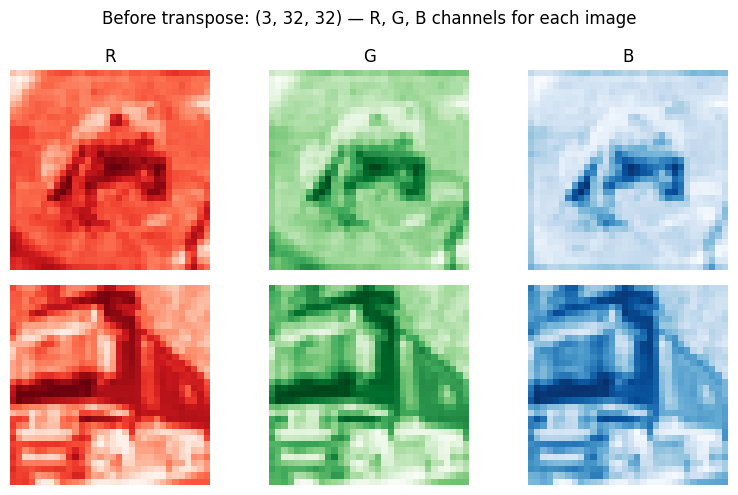

In [100]:
# Same two images, but in their form BEFORE transpose: (3, 32, 32) = channels × height × width
# Each row shows one image's R, G, B channels (no transpose applied)
def before_transpose(row):
    return row.reshape(3, 32, 32)  # (3, 32, 32) — channels first

fig, axes = plt.subplots(2, 3, figsize=(8, 5))
for i in range(2):  # image 0 and image 1
    img = before_transpose(data[i])  # (3, 32, 32)
    axes[i, 0].imshow(img[0], cmap='Reds')
    axes[i, 0].set_ylabel(f'Image {i}', fontsize=10)
    axes[i, 0].set_title('R' if i == 0 else '')
    axes[i, 0].axis('off')
    axes[i, 1].imshow(img[1], cmap='Greens')
    axes[i, 1].set_title('G' if i == 0 else '')
    axes[i, 1].axis('off')
    axes[i, 2].imshow(img[2], cmap='Blues')
    axes[i, 2].set_title('B' if i == 0 else '')
    axes[i, 2].axis('off')
axes[0, 0].set_ylabel(f'Image 0 ({CIFAR10_CLASSES[batch[b"labels"][0]]})', fontsize=10)
axes[1, 0].set_ylabel(f'Image 1 ({CIFAR10_CLASSES[batch[b"labels"][1]]})', fontsize=10)
plt.suptitle('Before transpose: (3, 32, 32) — R, G, B channels for each image')
plt.tight_layout()
plt.show()

### Display a grid of sample images from the batch

We can't show **all** 10,000 images from one batch at once, but we can show a grid of samples (e.g. 20–30). Each image is one row of the numeric array, reshaped to 32×32×3.

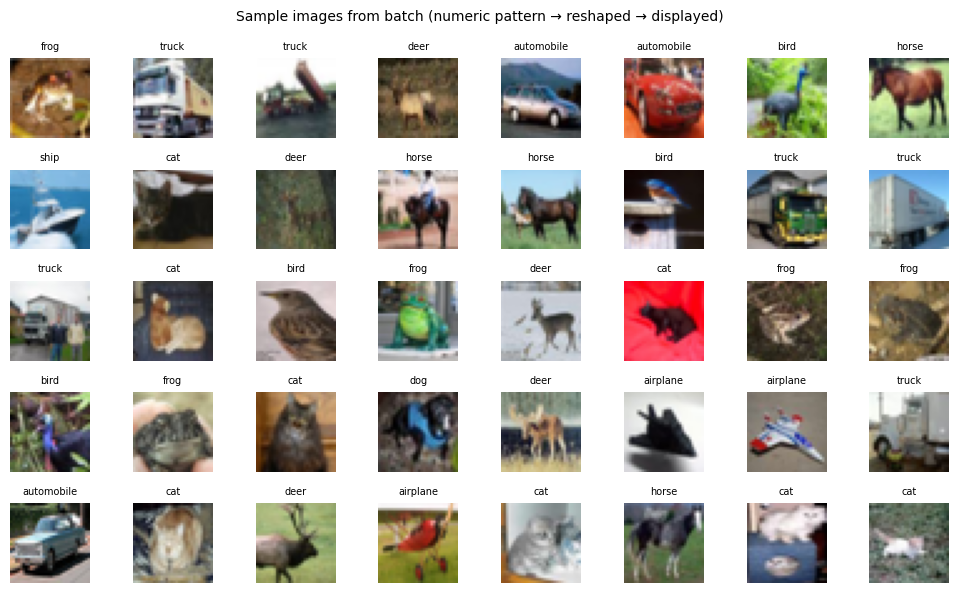

Displayed 40 images from the batch. Full batch has 10000 images.


In [101]:
# Grid of sample images from the same batch (data, batch from above)
# Show 5 rows × 8 columns = 40 images, with class name under each
n_show = 40  # number of images to display
rows, cols = 5, 8
fig, axes = plt.subplots(rows, cols, figsize=(10, 6))
for i in range(n_show):
    r, c = i // cols, i % cols
    row = data[i]  # one image: (3072,)
    img = row.reshape(3, 32, 32).transpose(1, 2, 0)  # (32, 32, 3)
    axes[r, c].imshow(img)
    axes[r, c].set_title(CIFAR10_CLASSES[batch[b'labels'][i]], fontsize=7)
    axes[r, c].axis('off')
plt.suptitle('Sample images from batch (numeric pattern → reshaped → displayed)', fontsize=10)
plt.tight_layout()
plt.show()
print(f'Displayed {n_show} images from the batch. Full batch has {data.shape[0]} images.')

---
# 7. HOG + Linear SVM classifier

- **HOG (Histogram of Oriented Gradients):** Extract HOG features from **grayscale** images.
- **Linear SVM:** Train a linear SVM on the HOG feature vectors.
- **Report:** Accuracy, confusion matrix, per-class precision and recall.

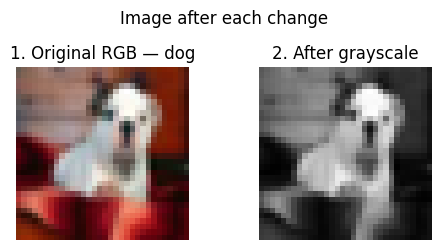

HOG feature shapes: (1500, 324) (300, 324)


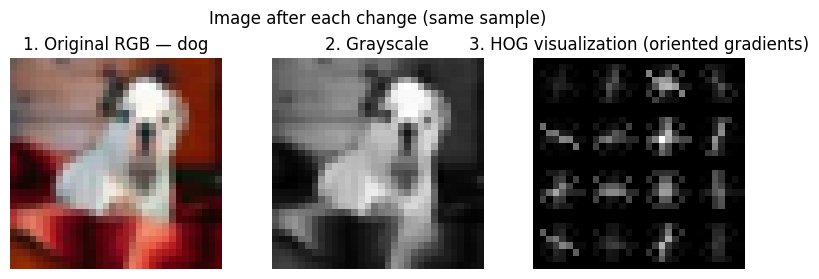


--- HOG + Linear SVM Report ---
Test accuracy: 0.8167 (81.67%)

Confusion matrix (rows=true, cols=predicted):
[[77 10 13]
 [13 80  7]
 [ 5  7 88]]
Classes: ['airplane', 'car', 'dog']

Per-class precision and recall:
  airplane: precision = 0.8105, recall = 0.7700
  car: precision = 0.8247, recall = 0.8000
  dog: precision = 0.8148, recall = 0.8800

Classification report:
              precision    recall  f1-score   support

    airplane       0.81      0.77      0.79       100
         car       0.82      0.80      0.81       100
         dog       0.81      0.88      0.85       100

    accuracy                           0.82       300
   macro avg       0.82      0.82      0.82       300
weighted avg       0.82      0.82      0.82       300



C:\Users\arzoo\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


In [ ]:
# HOG + Linear SVM: requires skimage and sklearn (install if needed: pip install scikit-image scikit-learn)
from skimage.feature import hog
from skimage import color
import time
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, classification_report

# If X_train_img / X_test_img were not created (e.g. reshape cell not run), build them from X_train / X_test
try:
    _ = X_train_img
except NameError:
    X_train_img = X_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)  # (N, 32, 32, 3)
    X_test_img = X_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    print('Built X_train_img, X_test_img from X_train, X_test (run section 5 for consistency).')

# --- 1) Convert RGB images to grayscale (use existing X_train_img, X_test_img from section 5) ---
def to_grayscale(imgs):
    """Convert (N, H, W, 3) RGB to (N, H, W) grayscale using standard weights."""
    return np.dot(imgs[..., :3], [0.299, 0.587, 0.114]).astype(np.uint8)

X_train_gray = to_grayscale(X_train_img)  # (1500, 32, 32)
X_test_gray = to_grayscale(X_test_img)    # (300, 32, 32)

# Display: original RGB → grayscale (one sample)
sample_idx = 0
fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))
axes[0].imshow(X_train_img[sample_idx])
axes[0].set_title(f'1. Original RGB — {SUBSET_CLASS_NAMES[y_train[sample_idx]]}')
axes[0].axis('off')
axes[1].imshow(X_train_gray[sample_idx], cmap='gray')
axes[1].set_title('2. After grayscale')
axes[1].axis('off')
plt.suptitle('Image after each change')
plt.tight_layout()
plt.show()

# --- 2) Extract HOG features for each image ---
# Common HOG params: 9 orientations, 8x8 pixels per cell, 2x2 cells per block
orientations = 9
pixels_per_cell = (8, 8)
cells_per_block = (2, 2)

def extract_hog_features(images_gray):
    features = []
    for img in images_gray:
        fd = hog(img, orientations=orientations, pixels_per_cell=pixels_per_cell,
                 cells_per_block=cells_per_block, block_norm='L2-Hys', visualize=False)
        features.append(fd)
    return np.array(features)

X_train_hog = extract_hog_features(X_train_gray)
X_test_hog = extract_hog_features(X_test_gray)
print('HOG feature shapes:', X_train_hog.shape, X_test_hog.shape)

# Display: same sample — grayscale and HOG visualization (HOG "image" shows gradient orientations)
_, hog_vis = hog(X_train_gray[sample_idx], orientations=orientations, pixels_per_cell=pixels_per_cell,
                 cells_per_block=cells_per_block, block_norm='L2-Hys', visualize=True)
fig, axes = plt.subplots(1, 3, figsize=(8, 2.8))
axes[0].imshow(X_train_img[sample_idx])
axes[0].set_title(f'1. Original RGB — {SUBSET_CLASS_NAMES[y_train[sample_idx]]}')
axes[0].axis('off')
axes[1].imshow(X_train_gray[sample_idx], cmap='gray')
axes[1].set_title('2. Grayscale')
axes[1].axis('off')
axes[2].imshow(hog_vis, cmap='gray')
axes[2].set_title('3. HOG visualization (oriented gradients)')
axes[2].axis('off')
plt.suptitle('Image after each change (same sample)')
plt.tight_layout()
plt.show()

# --- 3) Train linear SVM ---
start_hog = time.perf_counter()
svm = LinearSVC(max_iter=5000, random_state=42, C=0.1)
svm.fit(X_train_hog, y_train)
training_time_hog = time.perf_counter() - start_hog
y_pred = svm.predict(X_test_hog)

# --- 4) Report: accuracy, confusion matrix, per-class precision/recall ---
acc = accuracy_score(y_test, y_pred)
print('\n--- HOG + Linear SVM Report ---')
print(f'Test accuracy: {acc:.4f} ({acc*100:.2f}%)')

print('\nConfusion matrix (rows=true, cols=predicted):')
cm = confusion_matrix(y_test, y_pred)
print(cm)
print('Classes:', SUBSET_CLASS_NAMES)

print('\nPer-class precision and recall:')
precision = precision_score(y_test, y_pred, average=None, zero_division=0)
recall = recall_score(y_test, y_pred, average=None, zero_division=0)
for i, name in enumerate(SUBSET_CLASS_NAMES):
    print(f'  {name}: precision = {precision[i]:.4f}, recall = {recall[i]:.4f}')

print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=SUBSET_CLASS_NAMES, zero_division=0))

---
# 8. Color Histogram (HSV) + Random Forest

- **Color histograms:** Convert images to HSV and compute histograms with **8 bins per channel** (H, S, V) → 24-dimensional feature vector per image.
- **Random Forest:** Train a Random Forest classifier on these features.
- **Report:** Accuracy and **feature importance analysis** (which bins/channels matter most).

HSV histogram feature shape: (1500, 24) (8 bins × 3 channels = 24 dims)


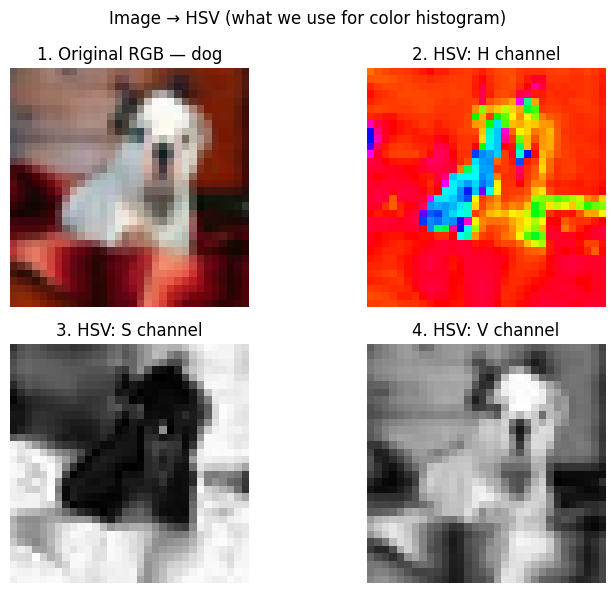

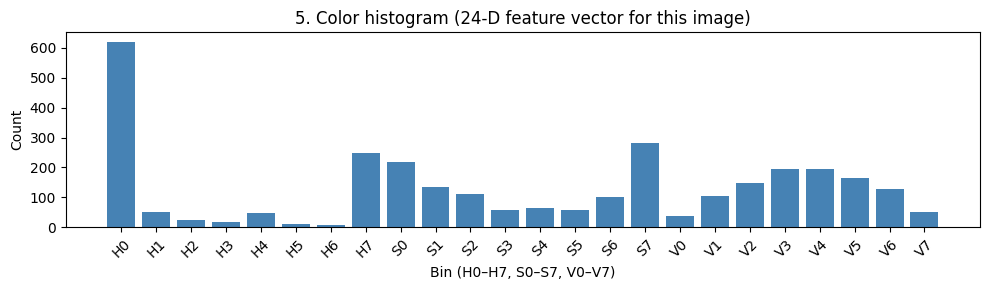


--- Color Histogram (HSV) + Random Forest Report ---
Test accuracy: 0.7067 (70.67%)
Training time: 0.50 seconds
Confusion matrix (rows=true, cols=predicted):
[[77 14  9]
 [ 8 70 22]
 [12 23 65]]

Feature importance (HSV bins):
  H0: 0.1094
  H4: 0.0961
  V1: 0.0741
  V3: 0.0642
  V2: 0.0516
  V0: 0.0515
  V4: 0.0488
  V5: 0.0455
  H5: 0.0398
  S2: 0.0354
  V7: 0.0349
  H7: 0.0325


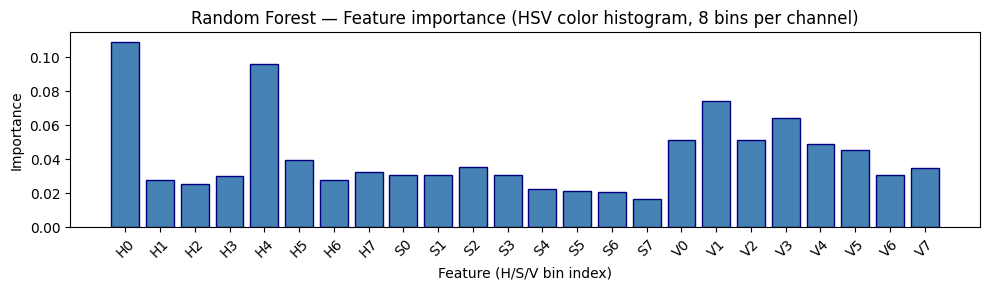

In [79]:
# Color Histogram (HSV) + Random Forest
import time
from skimage import color
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

try:
    _ = X_train_img
except NameError:
    X_train_img = X_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    X_test_img = X_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

# --- 1) Convert RGB to HSV and compute 8-bin histogram per channel (8+8+8 = 24 features) ---
def rgb_to_hsv_uint8(imgs):
    """Convert (N,H,W,3) RGB [0,255] to HSV; return (N,H,W,3) with H in [0,179], S,V in [0,255] for cv2-style."""
    imgs_float = imgs.astype(np.float32) / 255.0
    hsv = color.rgb2hsv(imgs_float)
    hsv[..., 0] = np.clip(hsv[..., 0] * 179, 0, 179)  # H: 0-1 -> 0-179
    hsv[..., 1:] = np.clip(hsv[..., 1:] * 255, 0, 255)  # S,V: 0-1 -> 0-255
    return hsv.astype(np.float32)

def color_histogram_hsv(imgs, bins_per_channel=8):
    """Extract HSV color histogram: 8 bins per channel -> 24-dim vector per image."""
    hsv = rgb_to_hsv_uint8(imgs)
    n = hsv.shape[0]
    H_bins, S_bins, V_bins = bins_per_channel, bins_per_channel, bins_per_channel
    features = np.zeros((n, H_bins + S_bins + V_bins))
    for i in range(n):
        h, s, v = hsv[i, :, :, 0].ravel(), hsv[i, :, :, 1].ravel(), hsv[i, :, :, 2].ravel()
        features[i, :H_bins], _ = np.histogram(h, bins=H_bins, range=(0, 180))
        features[i, H_bins:H_bins+S_bins], _ = np.histogram(s, bins=S_bins, range=(0, 256))
        features[i, H_bins+S_bins:], _ = np.histogram(v, bins=V_bins, range=(0, 256))
    return features

X_train_hsv = color_histogram_hsv(X_train_img, 8)
X_test_hsv = color_histogram_hsv(X_test_img, 8)
print('HSV histogram feature shape:', X_train_hsv.shape, '(8 bins × 3 channels = 24 dims)')

# Display what happened to the image: original → HSV channels → 24-bin histogram (the feature we use)
sample_hsv = 0
hsv_img = rgb_to_hsv_uint8(X_train_img[sample_hsv:sample_hsv+1])[0]
feat_names = [f'H{i}' for i in range(8)] + [f'S{i}' for i in range(8)] + [f'V{i}' for i in range(8)]
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes[0, 0].imshow(X_train_img[sample_hsv])
axes[0, 0].set_title(f'1. Original RGB — {SUBSET_CLASS_NAMES[y_train[sample_hsv]]}')
axes[0, 0].axis('off')
axes[0, 1].imshow(hsv_img[:, :, 0] / 179.0, cmap='hsv')
axes[0, 1].set_title('2. HSV: H channel')
axes[0, 1].axis('off')
axes[1, 0].imshow(hsv_img[:, :, 1], cmap='gray')
axes[1, 0].set_title('3. HSV: S channel')
axes[1, 0].axis('off')
axes[1, 1].imshow(hsv_img[:, :, 2], cmap='gray')
axes[1, 1].set_title('4. HSV: V channel')
axes[1, 1].axis('off')
plt.suptitle('Image → HSV (what we use for color histogram)')
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.bar(feat_names, X_train_hsv[sample_hsv], color='steelblue')
ax.set_xlabel('Bin (H0–H7, S0–S7, V0–V7)')
ax.set_ylabel('Count')
ax.set_title('5. Color histogram (24-D feature vector for this image)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 2) Train Random Forest ---
start_rf = time.perf_counter()
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train_hsv, y_train)
training_time_rf = time.perf_counter() - start_rf
y_pred_rf = rf.predict(X_test_hsv)

# --- 3) Report: accuracy, confusion matrix, and feature importance ---
acc_rf = accuracy_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)
print('\n--- Color Histogram (HSV) + Random Forest Report ---')
print(f'Test accuracy: {acc_rf:.4f} ({acc_rf*100:.2f}%)')
print(f'Training time: {training_time_rf:.2f} seconds')
print('Confusion matrix (rows=true, cols=predicted):')
print(cm_rf)

# Feature importance: 24 features = H0..H7, S0..S7, V0..V7
feat_names = [f'H{i}' for i in range(8)] + [f'S{i}' for i in range(8)] + [f'V{i}' for i in range(8)]
imp = rf.feature_importances_
print('\nFeature importance (HSV bins):')
for name, val in sorted(zip(feat_names, imp), key=lambda x: -x[1])[:12]:
    print(f'  {name}: {val:.4f}')
# Plot feature importance
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.bar(feat_names, imp, color='steelblue', edgecolor='navy')
ax.set_xlabel('Feature (H/S/V bin index)')
ax.set_ylabel('Importance')
ax.set_title('Random Forest — Feature importance (HSV color histogram, 8 bins per channel)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
# 9. SIFT + Bag-of-Visual-Words + SVM

- **Extract SIFT keypoints** (and descriptors) from each image (dense grid for 32×32).
- **Build visual vocabulary:** K-Means with **K=100** on all training descriptors → 100 visual words.
- **Create BoW representations:** Each image → histogram of visual word counts (100-dim vector).
- **Train SVM** on the BoW vectors.
- **Report:** Accuracy and **vocabulary visualization** (one training patch nearest to each visual word).

In [ ]:
# SIFT + Bag-of-Visual-Words + SVM
# Install OpenCV with contrib for SIFT (run once in terminal): pip install opencv-contrib-python
import time
import cv2
from sklearn.cluster import KMeans
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix

try:
    _ = X_train_img
except NameError:
    X_train_img = X_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    X_test_img = X_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
X_train_gray_sift = (np.dot(X_train_img[..., :3], [0.299, 0.587, 0.114])).astype(np.uint8)
X_test_gray_sift = (np.dot(X_test_img[..., :3], [0.299, 0.587, 0.114])).astype(np.uint8)

# --- 1) Extract SIFT descriptors (dense grid for 32x32 so we get enough per image) ---
try:
    sift = cv2.SIFT_create()
except AttributeError:
    sift = cv2.xfeatures2d.SIFT_create()

def get_sift_descriptors(gray_imgs):
    all_descs = []
    per_image_descs = []
    for img in gray_imgs:
        # Dense keypoints every 4 pixels so we get many 128-d descriptors
        kps = [cv2.KeyPoint(x, y, 8) for y in range(4, 28, 4) for x in range(4, 28, 4)]
        _, desc = sift.compute(img, kps)
        if desc is None or len(desc) == 0:
            _, desc = sift.detectAndCompute(img, None)
        if desc is None:
            desc = np.zeros((1, 128), dtype=np.float32)
        all_descs.append(desc)
        per_image_descs.append(desc)
    return all_descs, np.vstack([d for d in all_descs if d is not None and len(d) > 0])

train_descs_per_img, all_train_descs = get_sift_descriptors(X_train_gray_sift)
print('Total training descriptors for vocabulary:', all_train_descs.shape)
K_VOCAB = 100
kmeans = KMeans(n_clusters=K_VOCAB, random_state=42, n_init=10)
kmeans.fit(all_train_descs)
vocab_centers = kmeans.cluster_centers_  # (100, 128)

# --- 2) BoW: each image -> histogram of nearest vocab word counts ---
def bow_histogram(descs_per_image, vocab_centers):
    n = len(descs_per_image)
    K = vocab_centers.shape[0]
    histograms = np.zeros((n, K))
    for i, descs in enumerate(descs_per_image):
        if descs is None or len(descs) == 0:
            continue
        dists = np.linalg.norm(descs[:, None] - vocab_centers[None, :], axis=2)
        nearest = np.argmin(dists, axis=1)
        for w in nearest:
            histograms[i, w] += 1
        histograms[i] /= (histograms[i].sum() + 1e-8)
    return histograms

test_descs_per_img, _ = get_sift_descriptors(X_test_gray_sift)
X_train_bow = bow_histogram(train_descs_per_img, vocab_centers)
X_test_bow = bow_histogram(test_descs_per_img, vocab_centers)
print('BoW feature shape:', X_train_bow.shape)

# Display what happened to the image: original → grayscale with SIFT keypoints → BoW histogram
sample_bow = 0
img_gray = X_train_gray_sift[sample_bow]
kps = [cv2.KeyPoint(x, y, 8) for y in range(4, 28, 4) for x in range(4, 28, 4)]
img_kp = cv2.drawKeypoints(img_gray, kps, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(X_train_img[sample_bow])
axes[0].set_title(f'1. Original RGB — {SUBSET_CLASS_NAMES[y_train[sample_bow]]}')
axes[0].axis('off')
axes[1].imshow(img_kp, cmap='gray')
axes[1].set_title('2. Grayscale + SIFT keypoints (dense grid)')
axes[1].axis('off')
axes[2].bar(range(100), X_train_bow[sample_bow], color='green', alpha=0.7)
axes[2].set_xlabel('Visual word index')
axes[2].set_ylabel('Normalized count')
axes[2].set_title('3. BoW histogram (100-D feature for this image)')
plt.suptitle('Image → SIFT → BoW (what we feed to SVM)')
plt.tight_layout()
plt.show()

# --- 3) Train SVM ---
start_bow = time.perf_counter()
svm_bow = LinearSVC(max_iter=5000, random_state=42, C=0.1)
svm_bow.fit(X_train_bow, y_train)
training_time_bow = time.perf_counter() - start_bow
y_pred_bow = svm_bow.predict(X_test_bow)
acc_bow = accuracy_score(y_test, y_pred_bow)
cm_bow = confusion_matrix(y_test, y_pred_bow)

# --- Report: accuracy and summary of steps ---
print('\n--- SIFT + BoW + SVM Report ---')
print('  • Extract SIFT keypoints: done (dense grid per image → 128-d descriptors)')
print('  • Build visual vocabulary: done (K-Means with K=100)')
print('  • Create BoW representations: done (100-dim histogram per image)')
print('  • Train SVM: done (LinearSVC on BoW vectors)')
print(f'  • Accuracy: {acc_bow:.4f} ({acc_bow*100:.2f}%)')
print(f'  • Training time: {training_time_bow:.2f} seconds')
print('  • Confusion matrix (rows=true, cols=predicted):')
print(cm_bow)
print('  • Vocabulary visualization: below (10×10 grid, one patch per visual word)')

# --- 4) Vocabulary visualization: for each visual word, show training image whose descriptor is closest ---
# Build mapping from flat descriptor index to image index (same order as all_train_descs)
desc_to_img = []
for i, descs in enumerate(train_descs_per_img):
    if descs is not None and len(descs) > 0:
        for _ in range(len(descs)):
            desc_to_img.append(i)
desc_to_img = np.array(desc_to_img) if desc_to_img else np.zeros(all_train_descs.shape[0], dtype=int)

fig, axes = plt.subplots(10, 10, figsize=(8, 8))
axes = axes.ravel()
for k in range(K_VOCAB):
    dists = np.linalg.norm(all_train_descs - vocab_centers[k], axis=1)
    idx_flat = np.argmin(dists)
    img_idx = desc_to_img[idx_flat] if idx_flat < len(desc_to_img) else 0
    patch = X_train_gray_sift[img_idx]
    axes[k].imshow(patch, cmap='gray')
    axes[k].axis('off')
plt.suptitle('Vocabulary visualization: training patch nearest to each of 100 visual words', fontsize=9)
plt.tight_layout()
plt.show()

Total training descriptors for vocabulary: (54000, 128)


---
# 10. Simple CNN (own design)

- **Architecture:** 4–5 layer CNN (Conv → Conv → Pool → Conv → Pool → Dense → output).
- **Train from scratch** on the 3-class subset (no pretrained weights).
- **Report:** Accuracy, **training curves** (loss and accuracy vs epoch), and **learned filters** from the first conv layer.

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 291,043 (1.11 MB)

 Trainable params: 291,043 (1.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4801 - loss: 1.0188 - val_accuracy: 0.7200 - val_loss: 0.7116
Epoch 2/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7073 - loss: 0.7177 - val_accuracy: 0.7833 - val_loss: 0.5153
Epoch 3/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7745 - loss: 0.5912 - val_accuracy: 0.7767 - val_loss: 0.5447
Epoch 4/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7950 - loss: 0.5035 - val_accuracy: 0.7867 - val_loss: 0.5154
Epoch 5/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8502 - loss: 0.3950 - val_accuracy: 0.8700 - val_loss: 0.3307
Epoch 6/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8968 - loss: 0.3171 - val_accuracy: 0.8100 - val_loss: 0.4151
Epoch 7/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8968 - loss: 0.2928 - val_accuracy: 0.8900 - val_loss: 0.2895
Epoch 8/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9343 - loss: 0.1921 - val_accuracy: 0.9033 - v

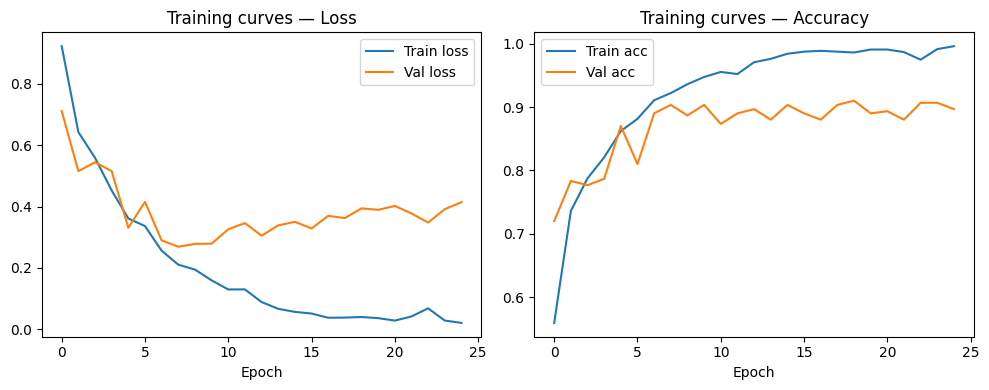

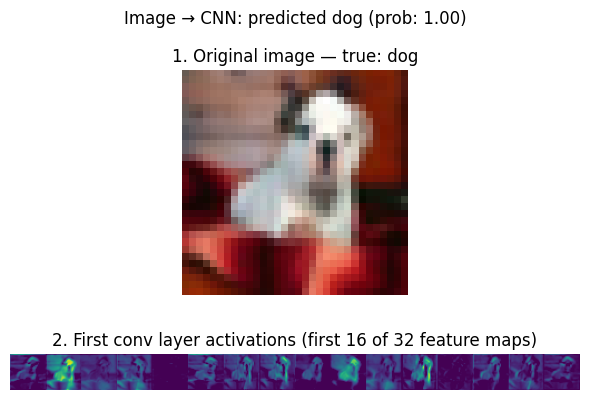

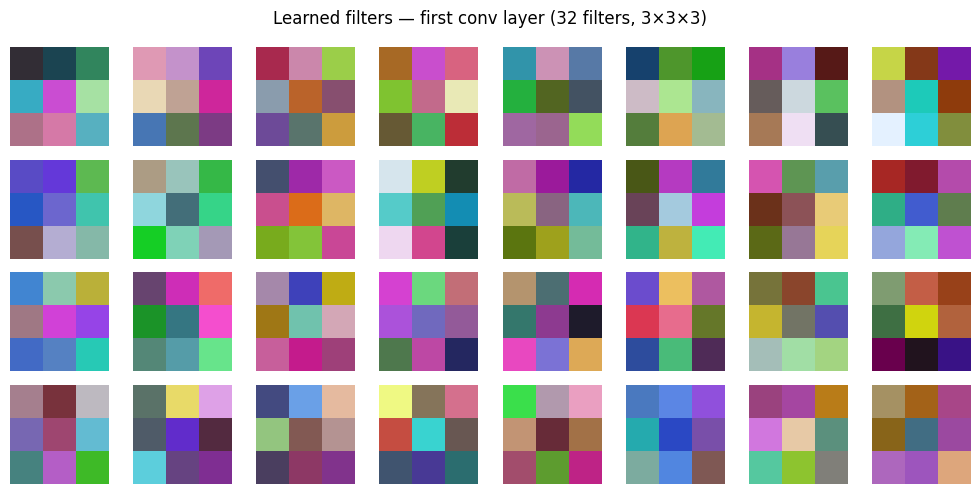

In [ ]:
# Simple CNN (requires TensorFlow: pip install tensorflow)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

try:
    _ = X_train_img
except NameError:
    X_train_img = X_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    X_test_img = X_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

# Normalize to [0,1] for CNN
X_train_cnn = X_train_img.astype(np.float32) / 255.0
X_test_cnn = X_test_img.astype(np.float32) / 255.0
# One-hot labels for 3 classes
y_train_oh = keras.utils.to_categorical(y_train, 3)
y_test_oh = keras.utils.to_categorical(y_test, 3)

# --- 1) Define 5-layer CNN: Conv -> Conv -> Pool -> Conv -> Pool -> Flatten -> Dense -> output ---
model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1'),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.build(input_shape=(None, 32, 32, 3))  # required so model.input is defined (Keras 3)
model.summary()

# --- 2) Train from scratch ---
start_cnn = time.perf_counter()
history = model.fit(X_train_cnn, y_train_oh, batch_size=32, epochs=25, validation_data=(X_test_cnn, y_test_oh), verbose=1)
training_time_cnn = time.perf_counter() - start_cnn

# --- 3) Report: accuracy, training curves ---
loss, acc_cnn = model.evaluate(X_test_cnn, y_test_oh, verbose=0)
y_pred_cnn = np.argmax(model.predict(X_test_cnn, verbose=0), axis=1)
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
print('\n--- Simple CNN Report ---')
print(f'Test accuracy: {acc_cnn:.4f} ({acc_cnn*100:.2f}%)')
print(f'Training time: {training_time_cnn:.2f} seconds')
print('Confusion matrix (rows=true, cols=predicted):')
print(cm_cnn)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history.history['loss'], label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_xlabel('Epoch')
axes[0].set_title('Training curves — Loss')
axes[0].legend()
axes[1].plot(history.history['accuracy'], label='Train acc')
axes[1].plot(history.history['val_accuracy'], label='Val acc')
axes[1].set_xlabel('Epoch')
axes[1].set_title('Training curves — Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

# Display what happened to the image: original → first conv layer activations → prediction
sample_cnn = 0
# Keras 3-safe extractor: avoid model.input/model.inputs (may be undefined in some run orders)
# Reuse the trained conv1 layer on a fresh Input tensor.
extract_in = keras.Input(shape=(32, 32, 3))
extract_out = model.get_layer('conv1')(extract_in)
conv1_model = keras.Model(inputs=extract_in, outputs=extract_out)
act = conv1_model.predict(X_train_cnn[sample_cnn:sample_cnn+1], verbose=0)
act = act[0]  # (32, 32, 32) - 32 feature maps
pred = model.predict(X_train_cnn[sample_cnn:sample_cnn+1], verbose=0)
pred_class = np.argmax(pred[0])
fig, axes = plt.subplots(2, 1, figsize=(6, 5))
axes[0].imshow(X_train_img[sample_cnn])
axes[0].set_title(f'1. Original image — true: {SUBSET_CLASS_NAMES[y_train[sample_cnn]]}')
axes[0].axis('off')
# Show first 16 feature maps from conv1 (what the image becomes after first layer)
grid = np.hstack([act[:, :, i] for i in range(16)])
axes[1].imshow(grid, cmap='viridis')
axes[1].set_title('2. First conv layer activations (first 16 of 32 feature maps)')
axes[1].axis('off')
plt.suptitle(f'Image → CNN: predicted {SUBSET_CLASS_NAMES[pred_class]} (prob: {pred[0][pred_class]:.2f})')
plt.tight_layout()
plt.show()

# --- 4) Learned filters (first conv layer: 32 filters of 3x3x3) ---
w = model.get_layer('conv1').get_weights()[0]  # (3, 3, 3, 32)
w = w - w.min()
w = w / (w.max() + 1e-8)
fig, axes = plt.subplots(4, 8, figsize=(10, 5))
for i in range(32):
    ax = axes[i // 8, i % 8]
    # Show 3x3 filter as RGB (average across input channels or show as 3x3 patch)
    filt = w[:, :, :, i]
    ax.imshow(filt)
    ax.axis('off')
plt.suptitle('Learned filters — first conv layer (32 filters, 3×3×3)')
plt.tight_layout()
plt.show()

=== Accuracy + Training Time Comparison ===
Method                              |   Accuracy | Accuracy (%) | Train Time (s)
----------------------------------------------------------------------------------
HOG + Linear SVM                    |     0.8167 |        81.67 |           0.08
HSV Histogram + Random Forest       |     0.7067 |        70.67 |           0.50
SIFT + BoW + SVM                    |     0.6633 |        66.33 |            N/A
Simple CNN                          |     0.8967 |        89.67 |            N/A


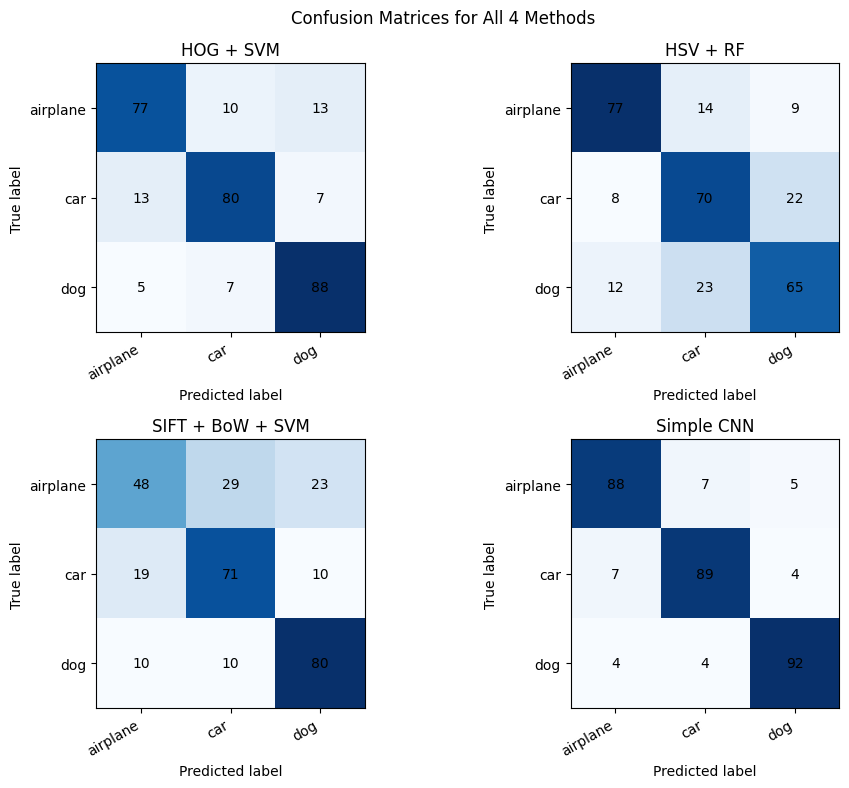


Note: If any value is N/A or matrix is unavailable, run that model section first, then rerun this deliverables cell.


In [81]:
# Final comparison: Accuracy table + Training time table + Confusion matrices for all methods
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Build/refresh confusion matrices in case any were not stored earlier
cm_hog = confusion_matrix(y_test, y_pred) if 'y_pred' in globals() else None
cm_rf = confusion_matrix(y_test, y_pred_rf) if 'y_pred_rf' in globals() else None
cm_bow = confusion_matrix(y_test, y_pred_bow) if 'y_pred_bow' in globals() else None
if 'y_pred_cnn' not in globals() and 'model' in globals() and 'X_test_cnn' in globals():
    y_pred_cnn = np.argmax(model.predict(X_test_cnn, verbose=0), axis=1)
cm_cnn = confusion_matrix(y_test, y_pred_cnn) if 'y_pred_cnn' in globals() else None

# Gather metrics (NaN if a section has not been run yet)
results = [
    ('HOG + Linear SVM', acc if 'acc' in globals() else np.nan, training_time_hog if 'training_time_hog' in globals() else np.nan),
    ('HSV Histogram + Random Forest', acc_rf if 'acc_rf' in globals() else np.nan, training_time_rf if 'training_time_rf' in globals() else np.nan),
    ('SIFT + BoW + SVM', acc_bow if 'acc_bow' in globals() else np.nan, training_time_bow if 'training_time_bow' in globals() else np.nan),
    ('Simple CNN', acc_cnn if 'acc_cnn' in globals() else np.nan, training_time_cnn if 'training_time_cnn' in globals() else np.nan),
]

print('=== Accuracy + Training Time Comparison ===')
print(f"{'Method':35s} | {'Accuracy':>10s} | {'Accuracy (%)':>12s} | {'Train Time (s)':>14s}")
print('-' * 82)
for method, acc_i, t_i in results:
    acc_txt = f"{acc_i:.4f}" if not np.isnan(acc_i) else 'N/A'
    acc_pct_txt = f"{acc_i * 100:.2f}" if not np.isnan(acc_i) else 'N/A'
    t_txt = f"{t_i:.2f}" if not np.isnan(t_i) else 'N/A'
    print(f"{method:35s} | {acc_txt:>10s} | {acc_pct_txt:>12s} | {t_txt:>14s}")

# Plot confusion matrices for all methods in one figure
cms = [
    ('HOG + SVM', cm_hog),
    ('HSV + RF', cm_rf),
    ('SIFT + BoW + SVM', cm_bow),
    ('Simple CNN', cm_cnn),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for i, (title, cm_i) in enumerate(cms):
    ax = axes[i]
    if cm_i is None:
        ax.axis('off')
        ax.set_title(f'{title}\n(not available yet)')
        continue

    ax.imshow(cm_i, cmap='Blues')
    ax.set_title(title)
    ax.set_xticks(range(len(SUBSET_CLASS_NAMES)))
    ax.set_yticks(range(len(SUBSET_CLASS_NAMES)))
    ax.set_xticklabels(SUBSET_CLASS_NAMES, rotation=30, ha='right')
    ax.set_yticklabels(SUBSET_CLASS_NAMES)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')

    for r in range(cm_i.shape[0]):
        for c in range(cm_i.shape[1]):
            ax.text(c, r, str(cm_i[r, c]), ha='center', va='center', color='black')

fig.suptitle('Confusion Matrices for All 4 Methods', fontsize=12)
plt.tight_layout()
plt.show()

print('\nNote: If any value is N/A or matrix is unavailable, run that model section first, then rerun this deliverables cell.')

## When would you use each approach?

- **HOG + SVM**
  - Use when you need a strong, classical baseline with low compute and good interpretability.
  - Works best when shape/edge information is important and color is less critical.

- **HSV Histogram + Random Forest**
  - Use when color distribution is a key signal and you want a very fast, simple method.
  - Good for quick experiments, but weaker when object shape/texture is needed.

- **SIFT + BoW + SVM**
  - Use when you want local keypoint/texture descriptors with some invariance to small geometric changes.
  - Useful as a handcrafted-feature pipeline, but more complex and often slower than HOG/HSV.

- **Simple CNN**
  - Use when you want end-to-end feature learning and generally best performance on image tasks.
  - Needs more data/compute/training time, but usually gives the strongest accuracy and flexibility.

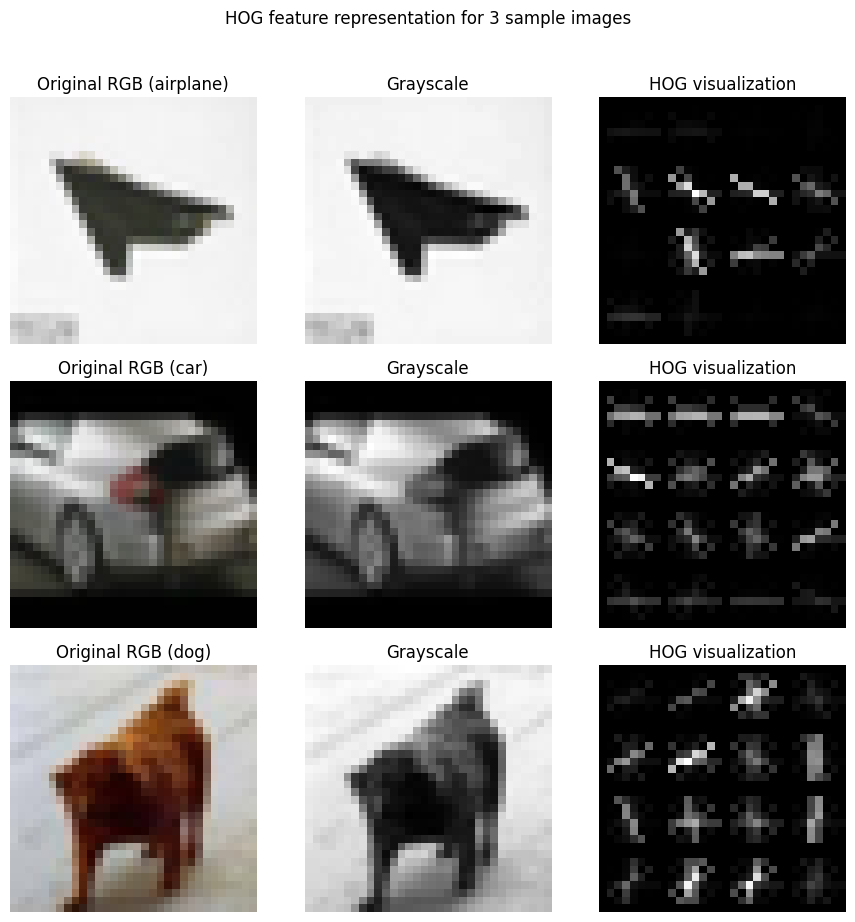

In [82]:
# HOG visualization for 3 sample images (one from each class)
from skimage.feature import hog
import numpy as np
import matplotlib.pyplot as plt

# Ensure image tensors exist
try:
    _ = X_test_img
except NameError:
    X_test_img = X_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

# Ensure grayscale exists
if 'X_test_gray' not in globals():
    X_test_gray = np.dot(X_test_img[..., :3], [0.299, 0.587, 0.114]).astype(np.uint8)

# Pick 3 samples: first test image from each class
sample_idxs = []
for c in range(3):
    idx_c = np.where(y_test == c)[0]
    if len(idx_c) > 0:
        sample_idxs.append(int(idx_c[0]))

orientations = 9
pixels_per_cell = (8, 8)
cells_per_block = (2, 2)

fig, axes = plt.subplots(len(sample_idxs), 3, figsize=(9, 3 * len(sample_idxs)))
if len(sample_idxs) == 1:
    axes = np.array([axes])

for r, idx in enumerate(sample_idxs):
    img_rgb = X_test_img[idx]
    img_gray = X_test_gray[idx]
    _, hog_vis = hog(
        img_gray,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm='L2-Hys',
        visualize=True
    )

    axes[r, 0].imshow(img_rgb)
    axes[r, 0].set_title(f'Original RGB ({SUBSET_CLASS_NAMES[y_test[idx]]})')
    axes[r, 0].axis('off')

    axes[r, 1].imshow(img_gray, cmap='gray')
    axes[r, 1].set_title('Grayscale')
    axes[r, 1].axis('off')

    axes[r, 2].imshow(hog_vis, cmap='gray')
    axes[r, 2].set_title('HOG visualization')
    axes[r, 2].axis('off')

plt.suptitle('HOG feature representation for 3 sample images', y=1.02)
plt.tight_layout()
plt.show()

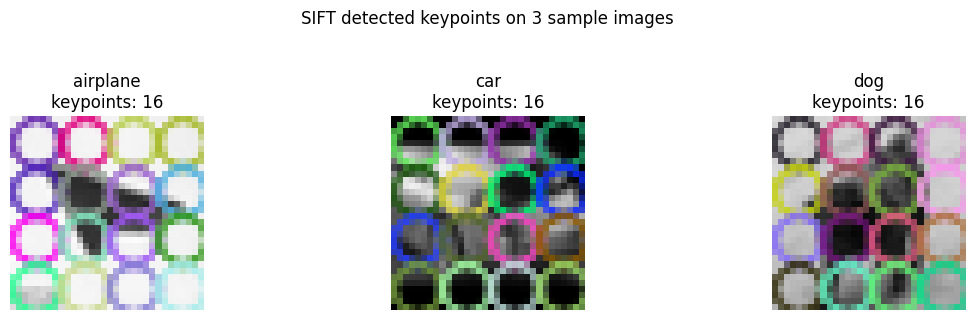

In [83]:
# SIFT keypoints on 3 sample images
import cv2

# Ensure grayscale exists for SIFT
if 'X_test_gray_sift' not in globals():
    X_test_gray_sift = (np.dot(X_test_img[..., :3], [0.299, 0.587, 0.114])).astype(np.uint8)

# Create SIFT detector
try:
    sift_vis = cv2.SIFT_create()
except AttributeError:
    sift_vis = cv2.xfeatures2d.SIFT_create()

sample_idxs = []
for c in range(3):
    idx_c = np.where(y_test == c)[0]
    if len(idx_c) > 0:
        sample_idxs.append(int(idx_c[0]))

fig, axes = plt.subplots(1, len(sample_idxs), figsize=(4 * len(sample_idxs), 3))
if len(sample_idxs) == 1:
    axes = [axes]

for j, idx in enumerate(sample_idxs):
    img_gray = X_test_gray_sift[idx]
    kps = [cv2.KeyPoint(float(x), float(y), 8) for y in range(4, 32, 8) for x in range(4, 32, 8)]
    kps, _ = sift_vis.compute(img_gray, kps)
    if kps is None or len(kps) == 0:
        kps = sift_vis.detect(img_gray, None)
    img_kp = cv2.drawKeypoints(img_gray, kps, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    axes[j].imshow(img_kp, cmap='gray')
    axes[j].set_title(f'{SUBSET_CLASS_NAMES[y_test[idx]]}\nkeypoints: {0 if kps is None else len(kps)}')
    axes[j].axis('off')

plt.suptitle('SIFT detected keypoints on 3 sample images', y=1.05)
plt.tight_layout()
plt.show()

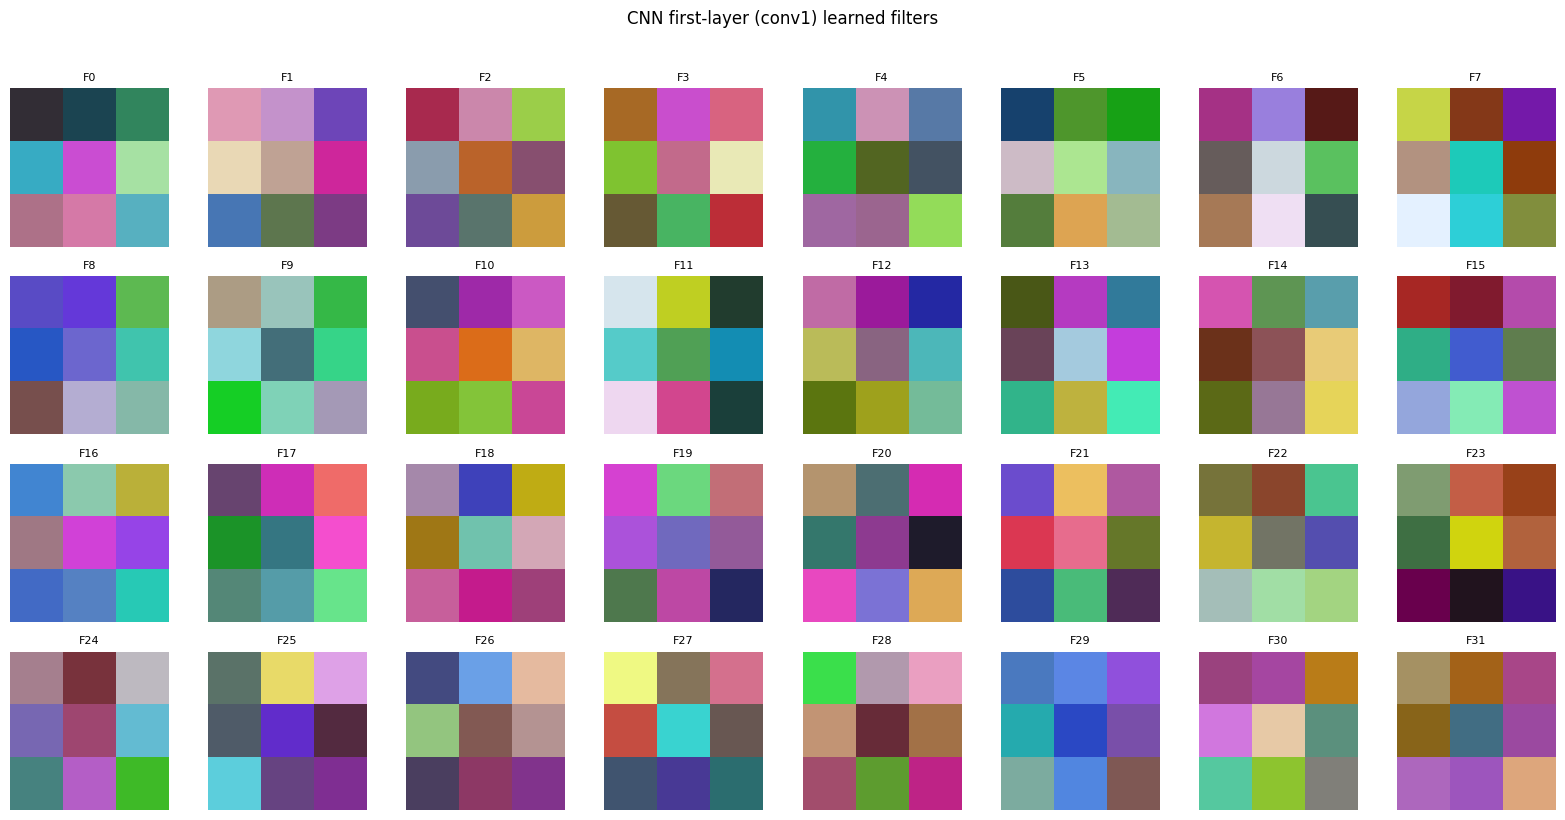

In [84]:
# CNN first-layer filters visualization
import numpy as np
import matplotlib.pyplot as plt

if 'model' not in globals():
    raise RuntimeError('CNN model not found. Run the Simple CNN section first.')

w = model.get_layer('conv1').get_weights()[0]  # (3, 3, 3, n_filters)
w = w - w.min()
w = w / (w.max() + 1e-8)

n_filters = w.shape[-1]
cols = 8
rows = int(np.ceil(n_filters / cols))
fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))
axes = np.array(axes).reshape(-1)

for i in range(rows * cols):
    ax = axes[i]
    if i < n_filters:
        ax.imshow(w[:, :, :, i])
        ax.set_title(f'F{i}', fontsize=8)
    ax.axis('off')

plt.suptitle('CNN first-layer (conv1) learned filters', y=1.02)
plt.tight_layout()
plt.show()

Error analysis method selected: Simple CNN


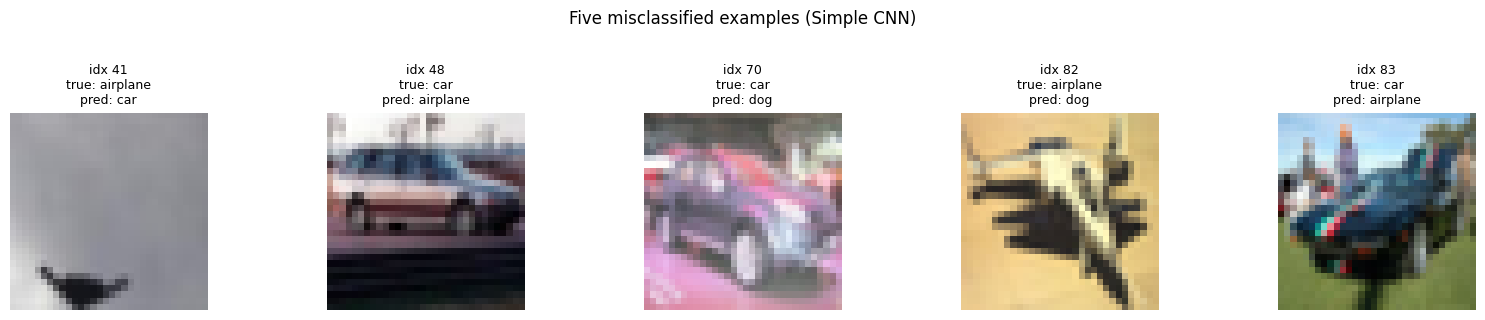


Feature-level explanations and suggested fixes:

Case 1 - index 41
  True class: airplane
  Pred class: car
  Why failed: Color distribution is closer to the predicted class (background/color bias).
  Why failed: Very few SIFT keypoints detected, so local texture cues are weak.
  Suggested fix: Apply data augmentation (color jitter/background variation) or object-centric cropping.
  Suggested fix: Increase image resolution or use dense descriptors/CNN features that need fewer keypoints.

Case 2 - index 48
  True class: car
  Pred class: airplane
  Why failed: The sample lies near class boundaries; features overlap strongly across classes.
  Suggested fix: Use feature fusion (HOG + color + deep embeddings) and more training data.

Case 3 - index 70
  True class: car
  Pred class: dog
  Why failed: Model is confidently wrong, likely due to learned shortcut features (spurious correlation).
  Suggested fix: Add harder negatives and regularization; inspect/clean mislabeled or biased sample

In [85]:
# Identify 5 misclassified images and explain why
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.metrics import confusion_matrix

# Choose method for error analysis (prefers CNN if available)
method_candidates = []
if 'y_pred_cnn' in globals():
    method_candidates.append(('Simple CNN', y_pred_cnn, acc_cnn if 'acc_cnn' in globals() else np.nan))
if 'y_pred' in globals():
    method_candidates.append(('HOG + Linear SVM', y_pred, acc if 'acc' in globals() else np.nan))
if 'y_pred_bow' in globals():
    method_candidates.append(('SIFT + BoW + SVM', y_pred_bow, acc_bow if 'acc_bow' in globals() else np.nan))
if 'y_pred_rf' in globals():
    method_candidates.append(('HSV + Random Forest', y_pred_rf, acc_rf if 'acc_rf' in globals() else np.nan))

if len(method_candidates) == 0:
    raise RuntimeError('No model predictions found. Run at least one model section first.')

# Pick highest-accuracy available method for analysis
method_name, y_pred_err, _ = sorted(method_candidates, key=lambda x: (-np.nan_to_num(x[2], nan=-1.0)))[0]
print(f'Error analysis method selected: {method_name}')

# Ensure base representations are available
try:
    _ = X_test_img
except NameError:
    X_test_img = X_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
if 'X_test_gray' not in globals():
    X_test_gray = np.dot(X_test_img[..., :3], [0.299, 0.587, 0.114]).astype(np.uint8)

# Optional helper features for reasoning
# HOG class centroids
hog_centroids = None
if 'X_train_gray' in globals() and 'y_train' in globals():
    X_train_hog_local = np.array([
        hog(img, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys', visualize=False)
        for img in X_train_gray
    ])
    hog_centroids = np.vstack([X_train_hog_local[y_train == c].mean(axis=0) for c in range(3)])

# HSV class centroids
hsv_centroids = None
if 'X_train_hsv' in globals():
    hsv_centroids = np.vstack([X_train_hsv[y_train == c].mean(axis=0) for c in range(3)])

# SIFT detector for keypoint count
try:
    import cv2
    try:
        sift_err = cv2.SIFT_create()
    except AttributeError:
        sift_err = cv2.xfeatures2d.SIFT_create()
except Exception:
    sift_err = None

# CNN probabilities if available
cnn_probs = None
if method_name == 'Simple CNN' and 'model' in globals() and 'X_test_cnn' in globals():
    cnn_probs = model.predict(X_test_cnn, verbose=0)

mis_idx = np.where(y_pred_err != y_test)[0]
if len(mis_idx) == 0:
    print('No misclassifications found for this method on the current split.')
else:
    pick = mis_idx[:5]

    # Show 5 misclassified images
    fig, axes = plt.subplots(1, len(pick), figsize=(3.2 * len(pick), 3))
    if len(pick) == 1:
        axes = [axes]

    for j, i in enumerate(pick):
        axes[j].imshow(X_test_img[i])
        axes[j].set_title(
            f'idx {i}\ntrue: {SUBSET_CLASS_NAMES[y_test[i]]}\npred: {SUBSET_CLASS_NAMES[y_pred_err[i]]}',
            fontsize=9
        )
        axes[j].axis('off')

    plt.suptitle(f'Five misclassified examples ({method_name})', y=1.05)
    plt.tight_layout()
    plt.show()

    def explain_one(i):
        true_c = int(y_test[i])
        pred_c = int(y_pred_err[i])
        img_gray = X_test_gray[i]
        contrast = float(np.std(img_gray))

        # HOG-nearest class check
        hog_reason = None
        if hog_centroids is not None:
            fd = hog(img_gray, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys', visualize=False)
            d = np.linalg.norm(hog_centroids - fd[None, :], axis=1)
            hog_near = int(np.argmin(d))
            hog_reason = (hog_near, d)

        # HSV-nearest class check
        hsv_reason = None
        if hsv_centroids is not None and 'color_histogram_hsv' in globals():
            hsv_f = color_histogram_hsv(X_test_img[i:i+1], 8)[0]
            d_hsv = np.linalg.norm(hsv_centroids - hsv_f[None, :], axis=1)
            hsv_near = int(np.argmin(d_hsv))
            hsv_reason = (hsv_near, d_hsv)

        # SIFT keypoint count
        kp_count = None
        if sift_err is not None:
            kps = sift_err.detect(img_gray, None)
            kp_count = 0 if kps is None else len(kps)

        reasons = []
        fixes = []

        if hog_reason is not None and hog_reason[0] == pred_c:
            reasons.append('Edge/shape pattern is closer to the predicted class in HOG feature space.')
            fixes.append('Use multi-scale HOG or combine HOG with color features to reduce shape-only confusion.')

        if hsv_reason is not None and hsv_reason[0] == pred_c:
            reasons.append('Color distribution is closer to the predicted class (background/color bias).')
            fixes.append('Apply data augmentation (color jitter/background variation) or object-centric cropping.')

        if kp_count is not None and kp_count < 10:
            reasons.append('Very few SIFT keypoints detected, so local texture cues are weak.')
            fixes.append('Increase image resolution or use dense descriptors/CNN features that need fewer keypoints.')

        if contrast < 28:
            reasons.append('Low contrast image reduces gradient quality and weakens handcrafted descriptors.')
            fixes.append('Use contrast normalization/CLAHE preprocessing and stronger augmentation.')

        if cnn_probs is not None:
            p = cnn_probs[i]
            pred_conf = float(p[pred_c])
            true_conf = float(p[true_c])
            if pred_conf > 0.80:
                reasons.append('Model is confidently wrong, likely due to learned shortcut features (spurious correlation).')
                fixes.append('Add harder negatives and regularization; inspect/clean mislabeled or biased samples.')
            elif pred_conf < 0.55:
                reasons.append('Prediction confidence is low, indicating class ambiguity at feature level.')
                fixes.append('Use larger model/retraining or test-time augmentation for ambiguous samples.')

        if len(reasons) == 0:
            reasons.append('The sample lies near class boundaries; features overlap strongly across classes.')
            fixes.append('Use feature fusion (HOG + color + deep embeddings) and more training data.')

        return reasons[:2], fixes[:2]

    print('\nFeature-level explanations and suggested fixes:\n')
    for rank, i in enumerate(pick, start=1):
        reasons, fixes = explain_one(int(i))
        print(f'Case {rank} - index {i}')
        print(f'  True class: {SUBSET_CLASS_NAMES[y_test[i]]}')
        print(f'  Pred class: {SUBSET_CLASS_NAMES[y_pred_err[i]]}')
        for r in reasons:
            print(f'  Why failed: {r}')
        for f in fixes:
            print(f'  Suggested fix: {f}')
        print('')